# User Behavior Analysis

**Business problem:** Users do not progress from low-intent behavior (views) to high-intent actions (cart/wishlist), resulting in weak conversion to purchase.

This notebook examines per-user behavioral signals to understand engagement depth and where the drop-off begins. Data source: `user_behavior_mart.sql`.

In [126]:
from src.db import run_sql
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

In [127]:
df = run_sql("../sql/user_behavior_mart.sql")
print(f"{df.shape[0]:,} users")
df.head()

10,000 users


,user_id,views_count,cart_adds,wishlist_adds,purchase_events,active_days,first_activity,last_activity
0,U000001,4,1,0,0,5,2024-01-13,2025-09-22
1,U000002,5,1,1,0,7,2024-05-31,2025-10-16
2,U000003,9,1,1,0,11,2024-03-25,2025-02-23
3,U000004,3,1,0,1,5,2024-04-20,2025-11-03
4,U000005,5,0,0,0,5,2024-05-10,2025-07-13


## 1. Summary Statistics

In [128]:
df[['views_count', 'cart_adds', 'wishlist_adds', 'purchase_events', 'active_days']].describe().round(2)

,views_count,cart_adds,wishlist_adds,purchase_events,active_days
count,10000.00,10000.0,10000.00,10000.00,10000.00
mean,5.60,1.2,0.79,0.40,7.95
std,2.35,1.1,0.89,0.63,2.78
min,0.00,0.0,0.00,0.00,0.00
25%,4.00,0.0,0.00,0.00,6.00
50%,5.00,1.0,1.00,0.00,8.00
75%,7.00,2.0,1.00,1.00,10.00
max,16.00,7.0,5.00,6.00,23.00


Median `purchase_events` is 0 - more than half of users have never made a purchase. The 25th percentile for `cart_adds` and `wishlist_adds` is also 0, meaning a significant share of users never move past browsing.

## 2. Distribution of Behavior Signals

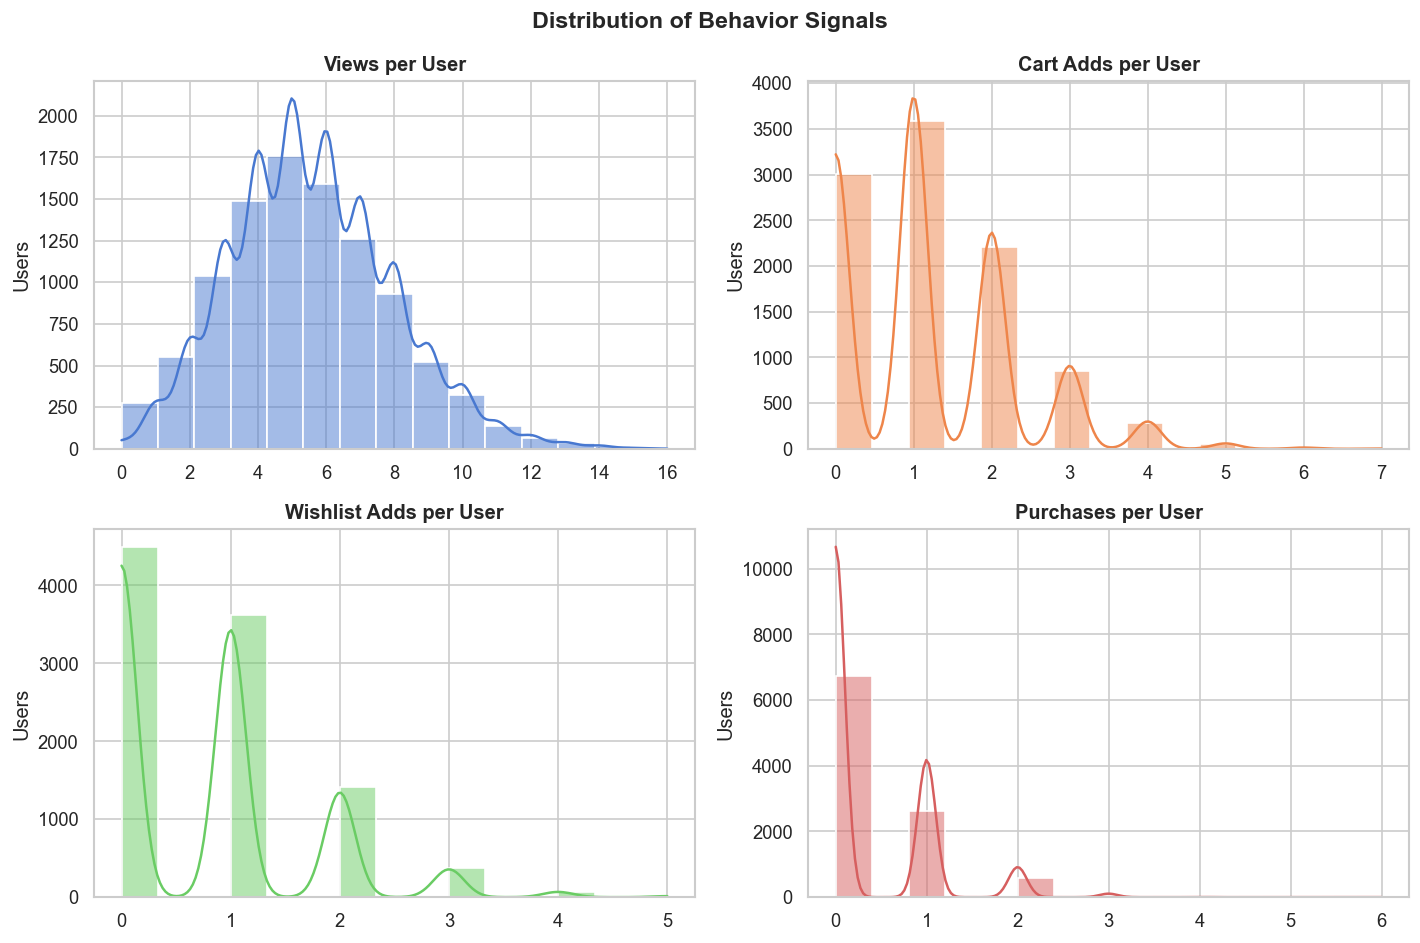

In [129]:
signals = [
    ("views_count",     "Views per User"),
    ("cart_adds",       "Cart Adds per User"),
    ("wishlist_adds",   "Wishlist Adds per User"),
    ("purchase_events", "Purchases per User"),
]

palette = sns.color_palette("muted")
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, (col, title) in enumerate(signals):
    sns.histplot(data=df, x=col, bins=15, kde=True, ax=axes[i], color=palette[i])
    axes[i].set_title(title, fontsize=12, fontweight="bold")
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Users")

fig.suptitle("Distribution of Behavior Signals", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

Views follow a roughly normal distribution. Cart adds, wishlist saves, and purchases are right-skewed with a large spike at zero - engagement drops sharply as intent level increases.

## 3. Intent Drop-Off

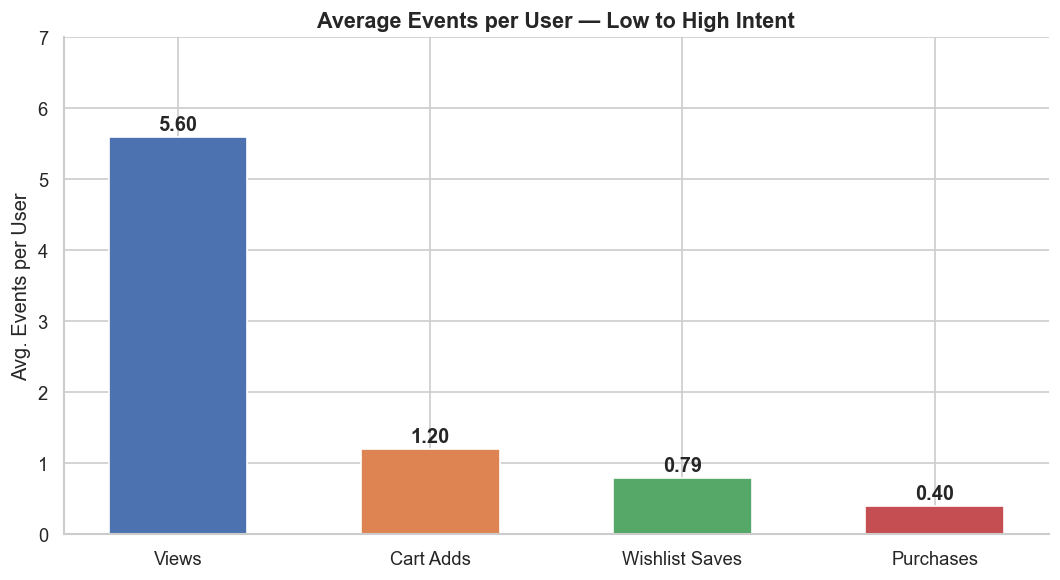

In [130]:
avg_vals = df[['views_count', 'cart_adds', 'wishlist_adds', 'purchase_events']].mean()
labels   = ['Views', 'Cart Adds', 'Wishlist Saves', 'Purchases']
colors   = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(labels, avg_vals.values, color=colors, width=0.55, edgecolor='white')

for bar, val in zip(bars, avg_vals.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.04,
            f"{val:.2f}", ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_title("Average Events per User — Low to High Intent", fontsize=13, fontweight='bold')
ax.set_ylabel("Avg. Events per User")
ax.set_ylim(0, avg_vals.max() * 1.25)
ax.tick_params(axis='x', labelsize=11)
sns.despine()
plt.tight_layout()
plt.show()

On average, users generate 5.6 views but only 0.4 purchases, a roughly 14x drop. Note that 0.4 avg purchases across all users is consistent with 32% of users being buyers (each buying ~1.25 times on average). The sharpest decline is between views and cart adds, that's the primary gap to investigate in the funnel analysis.

## 4. Buyer vs Non-Buyer Profile

In [131]:
df['is_buyer'] = df['purchase_events'] > 0

pct = df['is_buyer'].value_counts(normalize=True).mul(100).round(1)
print(f"Non-Buyers: {pct[False]}%  |  Buyers: {pct[True]}%")

metrics = ['views_count', 'cart_adds', 'wishlist_adds', 'active_days']
labels  = ['Views', 'Cart Adds', 'Wishlist Adds', 'Active Days']

summary = df.groupby('is_buyer')[metrics].mean().round(2)
summary.index = ['Non-Buyers', 'Buyers']
summary

Non-Buyers: 67.2%  |  Buyers: 32.8%


,views_count,cart_adds,wishlist_adds,active_days
Non-Buyers,5.57,1.2,0.79,7.52
Buyers,5.66,1.2,0.80,8.83


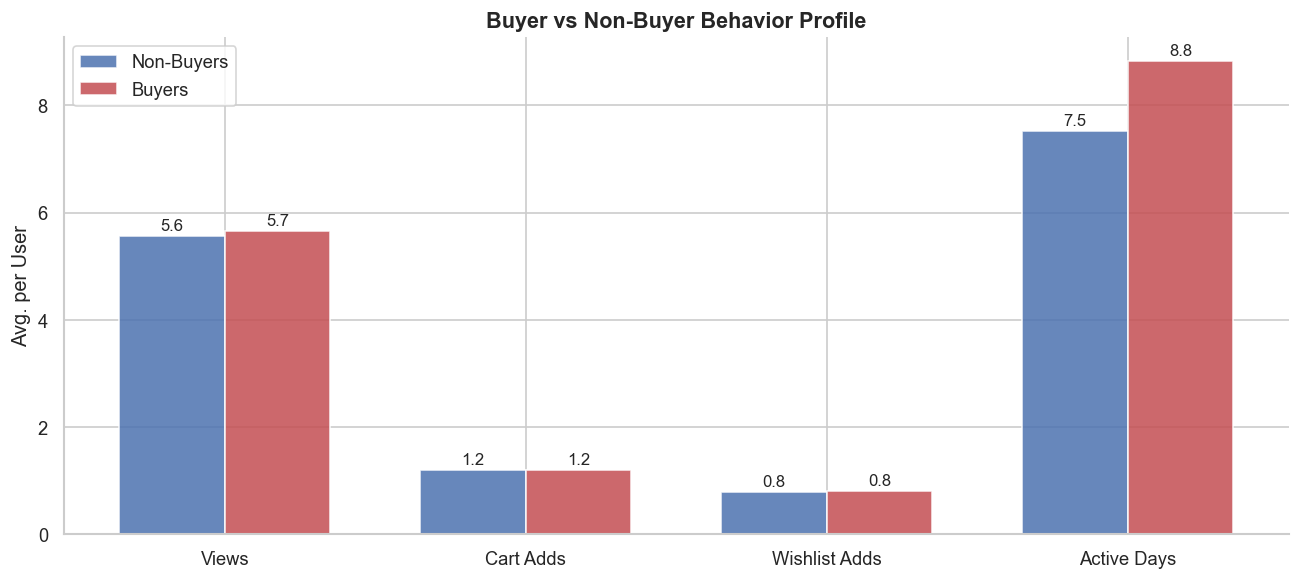

In [132]:
x     = range(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 5))

non_buyers = summary.loc['Non-Buyers', metrics].values
buyers     = summary.loc['Buyers',     metrics].values

bars1 = ax.bar([i - width/2 for i in x], non_buyers, width, label='Non-Buyers', color='#4C72B0', alpha=0.85)
bars2 = ax.bar([i + width/2 for i in x], buyers,     width, label='Buyers',     color='#C44E52', alpha=0.85)

for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
            f"{bar.get_height():.1f}", ha='center', va='bottom', fontsize=10)

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11)
ax.set_title("Buyer vs Non-Buyer Behavior Profile", fontsize=13, fontweight='bold')
ax.set_ylabel("Avg. per User")
ax.legend(fontsize=11)
sns.despine()
plt.tight_layout()
plt.show()

Buyers and non-buyers are nearly identical in views (5.57 vs 5.66), cart adds (1.2 vs 1.2), and wishlist saves (0.79 vs 0.80). The only visible difference is active_days (7.5 vs 8.8). Behavioral action counts alone don't separate the two groups, users who eventually buy don't appear to browse or add to cart significantly more than those who don't.

## 5. Active Days Distribution

Mean: 8.0 | Median: 8 | Max: 23


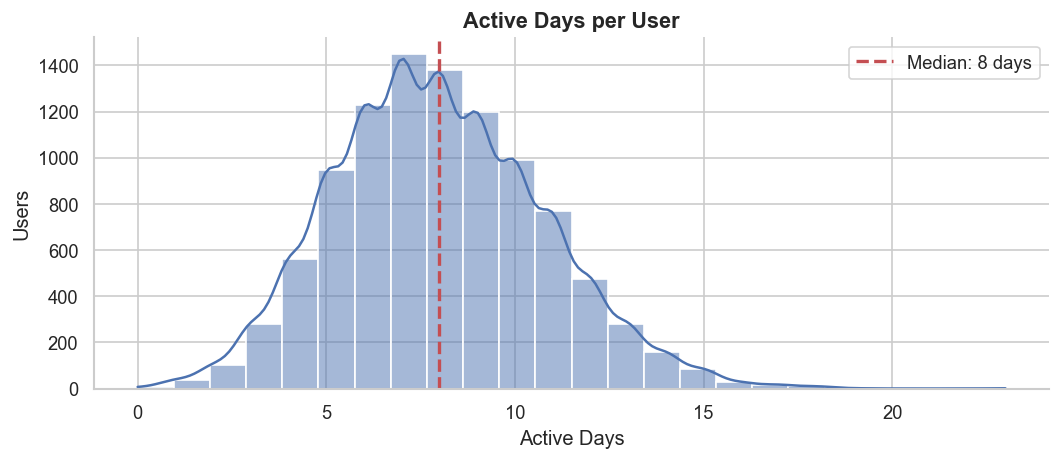

In [133]:
median_days = df['active_days'].median()
print(f"Mean: {df['active_days'].mean():.1f} | Median: {median_days:.0f} | Max: {df['active_days'].max()}")

fig, ax = plt.subplots(figsize=(9, 4))
sns.histplot(data=df, x='active_days', bins=24, kde=True, color='#4C72B0', ax=ax)
ax.axvline(median_days, color='#C44E52', linestyle='--', linewidth=2,
           label=f"Median: {median_days:.0f} days")
ax.set_title("Active Days per User", fontsize=13, fontweight='bold')
ax.set_xlabel("Active Days")
ax.set_ylabel("Users")
ax.legend(fontsize=11)
sns.despine()
plt.tight_layout()
plt.show()

Activity spans are roughly bell-shaped, centered around 8 days. Most users are active on 6–10 distinct days. Given that active_days is the only signal that meaningfully differs between buyers and non-buyers, return frequency is worth tracking as a leading indicator.

---

## Key Findings

- Over half of users have never made a purchase (median purchases = 0); 32% of users are buyers
- The view-to-purchase ratio is ~14x browsing volume alone doesn't drive conversion
- Cart adds and wishlist saves are nearly identical between buyers and non-buyers, these signals don't predict purchase in this dataset
- The only behavioral differentiator between buyers and non-buyers is session frequency (active_days: 8.8 vs 7.5)